In [1]:
import os
import cv2
import numpy as np

import sys
# add the parent of the parent directory to the path
sys.path.append('/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics')

sys.path.append('/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/model/calibrated-backprojection-network/src')

from depth_anything_wrapper import DepthAnythingWrapper

import data_utils 


# Set up the environment and our DepthAnything model
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
encoder = "vitl"
weights_path = "/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/Depth-Anything-V2-main/depth_anything_v2/depth_anything_v2_vitl.pth"
wrapper = DepthAnythingWrapper(model_weights_path=weights_path, encoder=encoder)


data_dir = "/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics"
image_dir = "/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/segmentation/subpixel-embedding-segmentation/evaluation_results/u-net/unet_traintest/test_scans/scan_color/scan_color_patient1.png"
depth_dir = "/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/data/scans_testing/SB/SB1Cback/data/depth/0000003618-1681416747736.9832.png"

# Create output directory for the fused dense depth maps
dense_depth_dir = os.path.join(data_dir, "dense_depth")
os.makedirs(dense_depth_dir, exist_ok=True)

# Form paths for the input image and the corresponding sensor depth
image_path = image_dir
sensor_depth_path = depth_dir
# Check that sensor depth exists.
if not os.path.exists(sensor_depth_path):
    print(f"Sensor depth file not found for {image_path}")

# Run DepthAnything to get a dense (relative) depth map
print(f"\nProcessing image: {image_path}")
dense_pred = wrapper.infer(image_path)
print(f"Dense prediction shape: {dense_pred.shape}")

# Load the sensor depth
sensor_depth = data_utils.load_depth(sensor_depth_path)

# Resize the dense prediction to match sensor depth shape if necessary
if sensor_depth.shape != dense_pred.shape:
    print(f"Resizing dense prediction from {dense_pred.shape} to {sensor_depth.shape}")
    dense_pred = cv2.resize(dense_pred, (sensor_depth.shape[1], sensor_depth.shape[0]))

valid_mask = sensor_depth > 0
if np.sum(valid_mask) < 10:
    print(f"Not enough valid sensor depth points for {image_path}")


sensor_inv = 1.0 / sensor_depth[valid_mask]
sensor_valid_inv = sensor_inv.reshape(-1, 1)
dense_valid_mask = dense_pred[valid_mask]
dense_valid       = dense_valid_mask.reshape(-1, 1)

# print shapes of sensor_valid and dense_valid
print(f"Sensor valid shape: {sensor_valid_inv.shape}")
print(f"Dense valid shape: {dense_valid.shape}")

/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/.venv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/.venv/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <9A4710B9-0DA3-36BB-9129-645F282E64B2> /Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/.venv/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <E3D17B4A-4867-3D49-BC92-E04C28EE0F45> /Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/.venv/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
xFormers not available
xFormers not avail

Loaded weights from /Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/Depth-Anything-V2-main/depth_anything_v2/depth_anything_v2_vitl.pth

Processing image: /Users/primary/Documents/GitHub/cs-thesis/3d-ergonomics/segmentation/subpixel-embedding-segmentation/evaluation_results/u-net/unet_traintest/test_scans/scan_color/scan_color_patient1.png
Dense prediction shape: (480, 640)
Sensor valid shape: (292406, 1)
Dense valid shape: (292406, 1)


In [45]:
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
import numpy as np

def compute_scale_and_bias(method, sensor_valid_inv, dense_valid, debug=True):
    if method == "ransac":
        ransac = RANSACRegressor(random_state=0)
        ransac.fit(dense_valid, sensor_valid_inv.ravel())
        scale = ransac.estimator_.coef_[0]
        bias  = ransac.estimator_.intercept_
        if debug:
            print(f"RANSAC fit for example -> scale: {scale:.3f}, bias: {bias:.3f}")
    elif method == "percentile":
        p0_d, p90_d = np.percentile(dense_valid,  [0, 90])
        p0_s, p90_s = np.percentile(sensor_valid_inv, [0, 90])
        
        print(f"p25_d: {p0_d:.3f}, p75_d: {p90_d:.3f}")
        print(f"p25_s: {p0_s:.3f}, p75_s: {p90_s:.3f}")
        

        # solve:  real ≈ scale·dense + bias
        scale = (p90_s - p0_s) / (p90_d - p0_d)
        bias  = p0_s - scale * p0_d

        if debug:
            print(f"Percentile fit → scale: {scale:.3f}, bias: {bias:.3f}")
    elif method == "median":
        scale = np.median(sensor_valid_inv) / np.median(dense_valid)
        bias  = 0.0
        
        if debug:
            print(f"Median fit for example -> scale: {scale:.3f}, bias: {bias:.3f}")
    elif method == "linear":
        linear = LinearRegression()
        linear.fit(dense_valid, sensor_valid_inv.ravel())
        scale = linear.coef_[0]
        bias  = linear.intercept_
        if debug:
            print(f"Linear fit for example -> scale: {scale:.3f}, bias: {bias:.3f}")
        
    return scale, bias


def plot_all_figures(scaling_method):
    scale, bias = compute_scale_and_bias(scaling_method, sensor_valid_inv, dense_valid)
        
    
    if scaling_method == "ransac":
        scaling_method_title = "RANSAC"
    elif scaling_method == "median":
        scaling_method_title = "Median"
    elif scaling_method == "linear":
        scaling_method_title = "Linear"
    elif scaling_method == "percentile":
        scaling_method_title = "Percentile"


    fused_dense = 1.0 / (dense_pred * scale + bias)
    plt.scatter(dense_valid, sensor_valid_inv, alpha=0.3, s=1)
    plt.xlabel("DepthAnything Inverse Depth (relative)")
    plt.ylabel("Inverse Sensor Depth (1/meters)")
    plt.title(f"{scaling_method_title} Fit to Data")
    plt.grid(True)

    # draw the line of best fit
    x_min, x_max = dense_valid.min(), dense_valid.max()
    x = np.linspace(x_min, x_max, 100).reshape(-1, 1)
    y = x * scale + bias
    plt.plot(x, y, color='red', linewidth=2)
    plt.show()
    

    # show original RGB image
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(f'Original Image')
    plt.axis('off')
    plt.show()

    # show original sensor depth
    plt.figure(figsize=(8, 6))
    plt.imshow(sensor_depth, cmap='plasma')
    plt.title(f'Sensor Depth')
    plt.colorbar(label='Depth (meters)')
    plt.axis('off')
    plt.show()

    sensor_inv_map = np.full_like(sensor_depth, np.nan)  # initialize all NaN
    sensor_inv_map[valid_mask] = sensor_inv
    # show inverted dense depth
    plt.figure(figsize=(8, 6))
    plt.imshow(sensor_inv_map, cmap='plasma')
    plt.title(f'Sensor Depth (inverted)')
    plt.colorbar(label='Inverse Depth (1/meters)')
    plt.axis('off')
    plt.show()

    # show depthanything
    plt.figure(figsize=(8, 6))
    plt.imshow(dense_pred, cmap='plasma')
    plt.title(f'DepthAnything Output')
    plt.colorbar(label='Inverse Depth (relative)')
    plt.axis('off')
    plt.show()

    # Create a masked version of the DepthAnything prediction
    masked_dense_pred = np.full_like(dense_pred, np.nan)  # initialize all NaN
    masked_dense_pred[valid_mask] = dense_pred[valid_mask]

    plt.figure(figsize=(8, 6))
    plt.imshow(masked_dense_pred, cmap='plasma')
    plt.title("DepthAnything Output (masked by sensor validity)")
    plt.colorbar(label='Inverse Depth (relative)')
    plt.axis('off')
    plt.show()

    # Display dense depth map
    plt.figure(figsize=(8, 6))
    plt.imshow(fused_dense, cmap='plasma')
    plt.title(f'Fused Dense Depth')
    plt.colorbar(label='Depth (meters)')
    plt.axis('off')
    plt.show()

    if scaling_method == "percentile" or scaling_method == "median":
        # --- Clamp and re‐plot the scatter + line cleanly ---
        x5, x95 = np.percentile(dense_valid, [0, 90])
        y5, y95 = np.percentile(sensor_valid_inv, [0, 90])
        x_clamped = np.clip(dense_valid, x5, x95)
        y_clamped = np.clip(sensor_valid_inv, y5, y95)

        plt.figure(figsize=(6,6))
        plt.scatter(x_clamped, y_clamped, alpha=0.3, s=1)
        # draw the line only over [x5,x95]
        xx = np.linspace(x5, x95, 100)
        yy = xx * scale + bias
        plt.plot(xx, yy, color="red", linewidth=2)

        # lock the view to your clamped window
        plt.xlim(x5, x95)
        plt.ylim(y5, y95)

        plt.xlabel("DepthAnything Depth (relative)")
        plt.ylabel("Sensor Depth (meters)")
        plt.title("Median Fit to Data (clamped at 90th percentile)")
        plt.grid(True)
        plt.show()

        # --- 2) Clamp the fused dense depth map ---
        # fused_dense was computed above as (1.0/dense_pred)*scale + bias
        fd = fused_dense
        fd10, fd90 = np.percentile(fd, [0, 80])
        fused_clipped = np.clip(fd, fd10, fd90)

        plt.figure(figsize=(8, 6))
        plt.imshow(fused_clipped, cmap="plasma")
        plt.title("Fused Dense Depth (clamped at 80th percentile)")
        plt.colorbar(label="Depth (meters)")
        plt.axis("off")
        plt.show()


RANSAC fit for example -> scale: 0.001, bias: 0.377


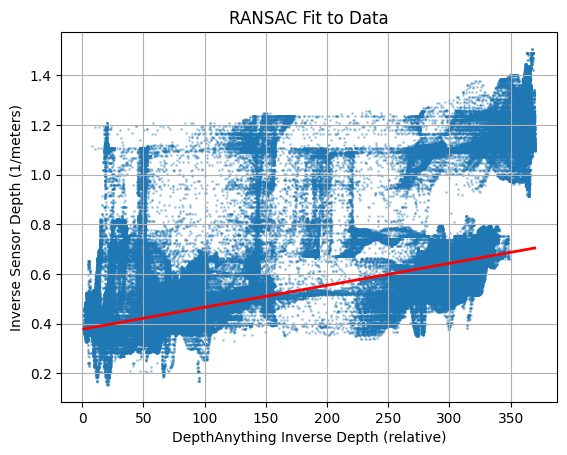

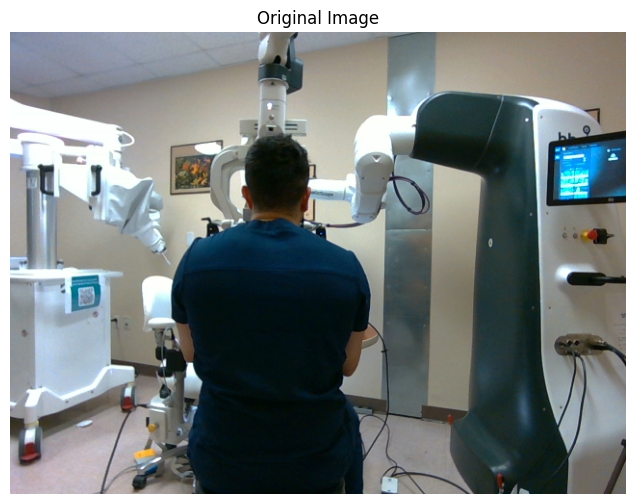

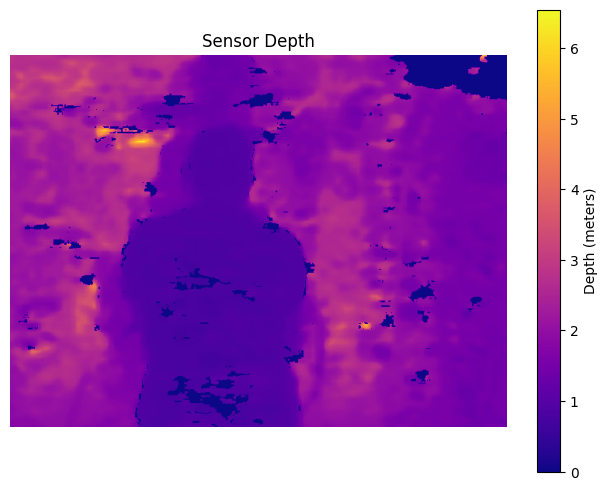

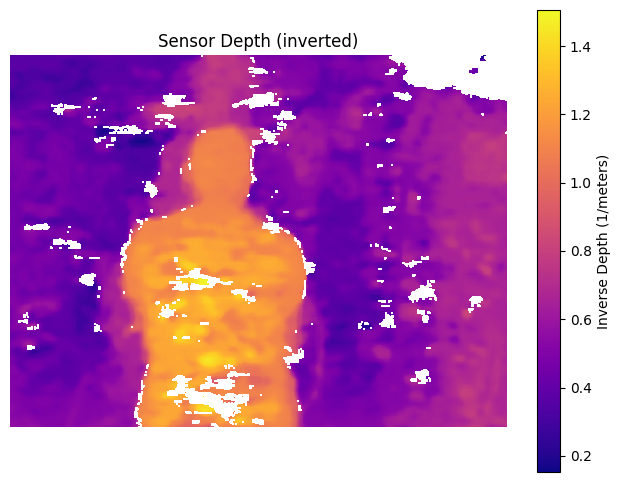

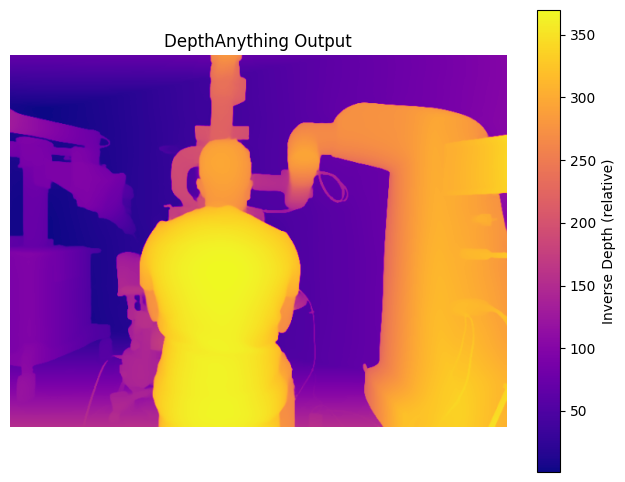

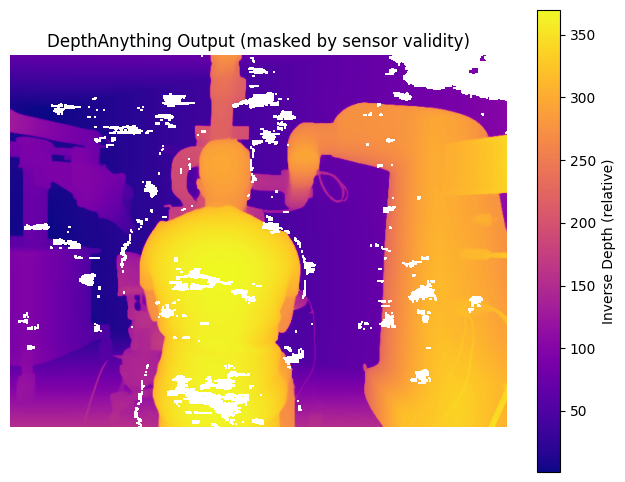

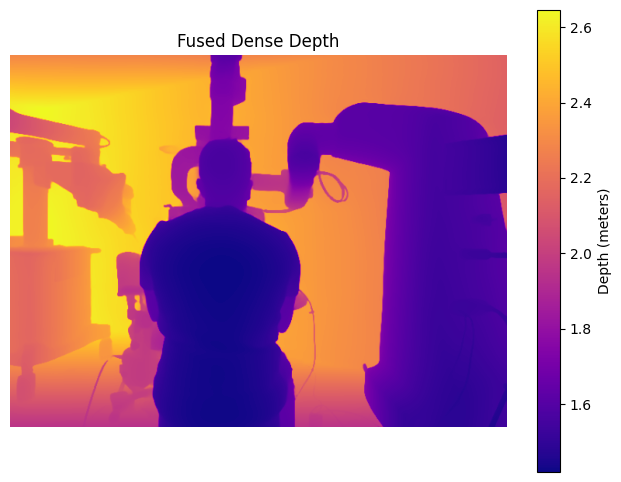

In [3]:
plot_all_figures("ransac")

Median fit for example -> scale: 0.004, bias: 0.000


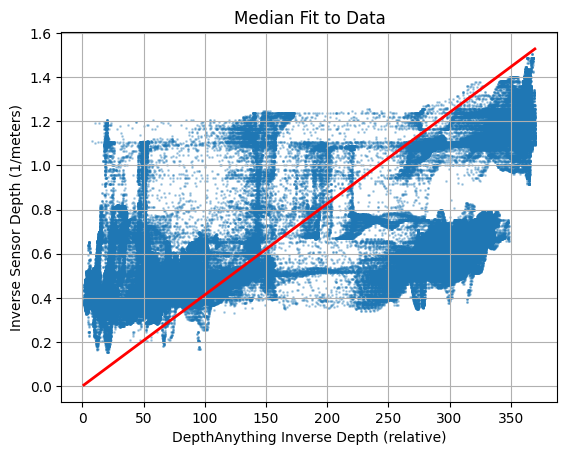

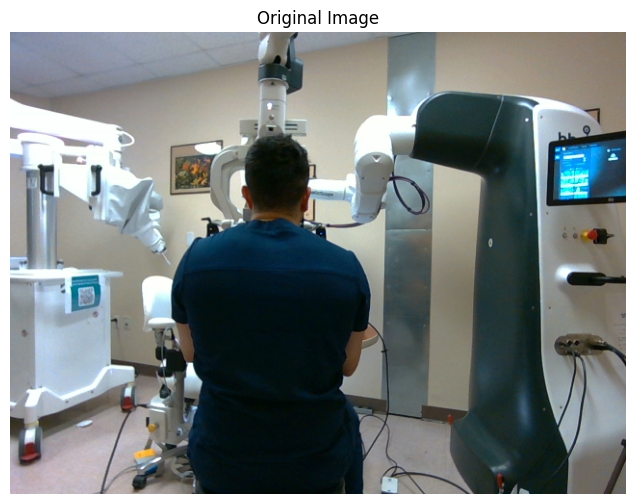

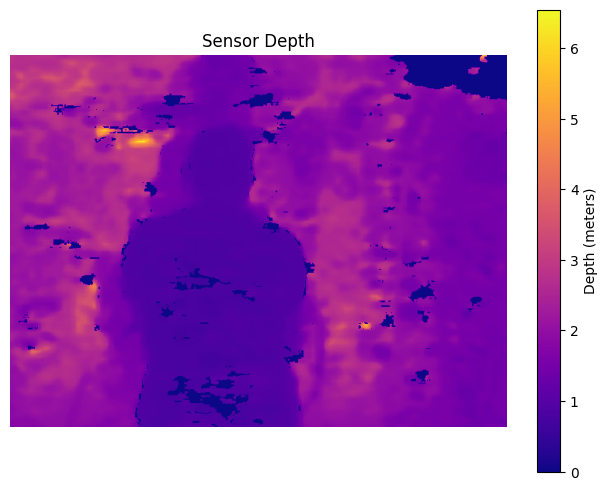

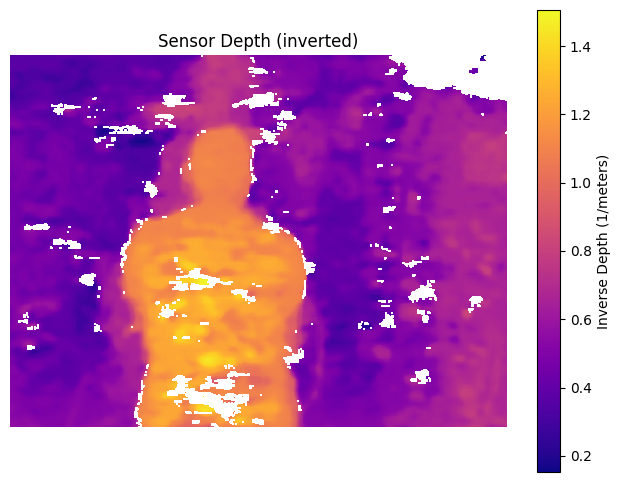

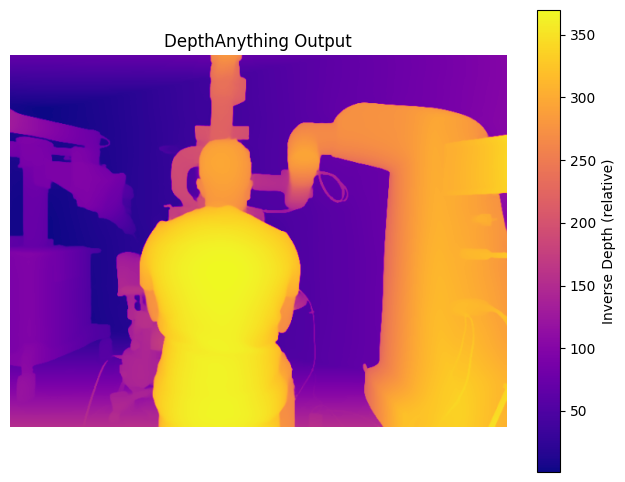

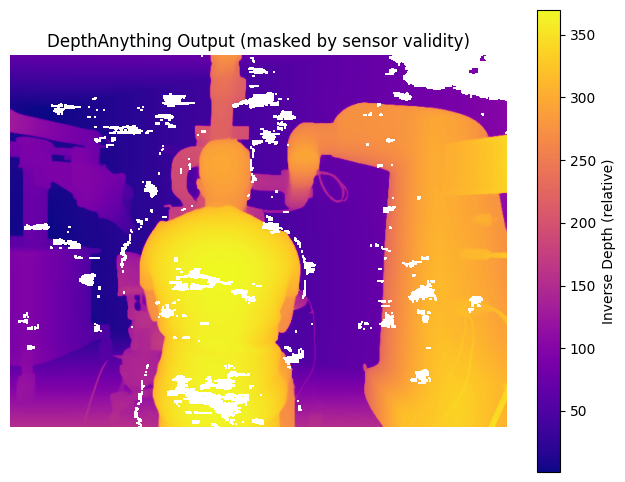

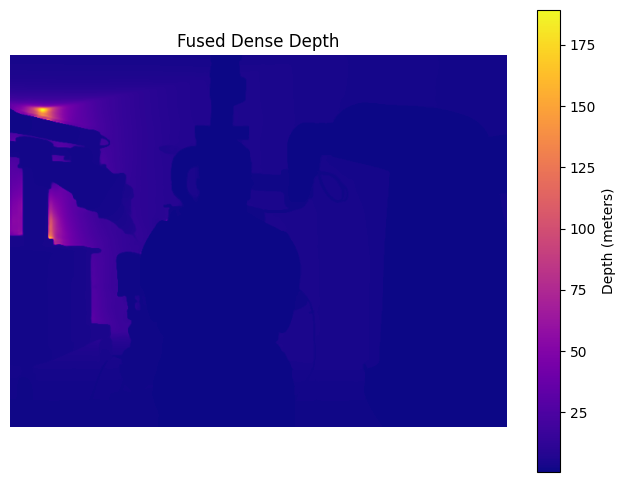

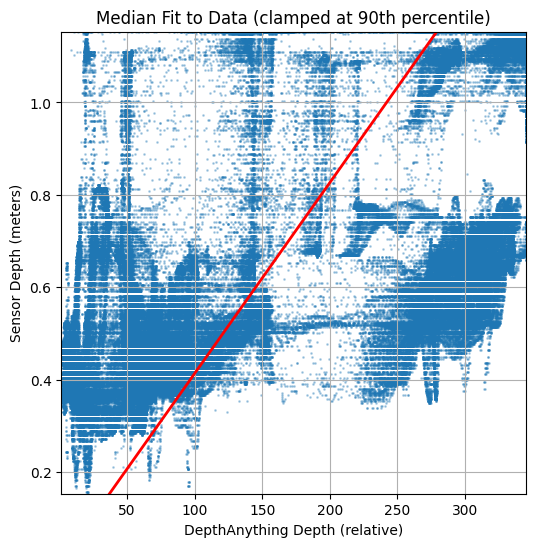

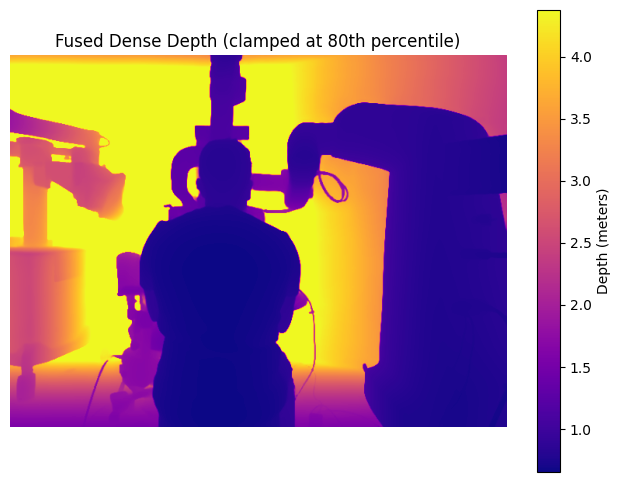

In [46]:
plot_all_figures("median")

p25_d: 1.278, p75_d: 345.272
p25_s: 0.153, p75_s: 1.153
Percentile fit → scale: 0.003, bias: 0.149


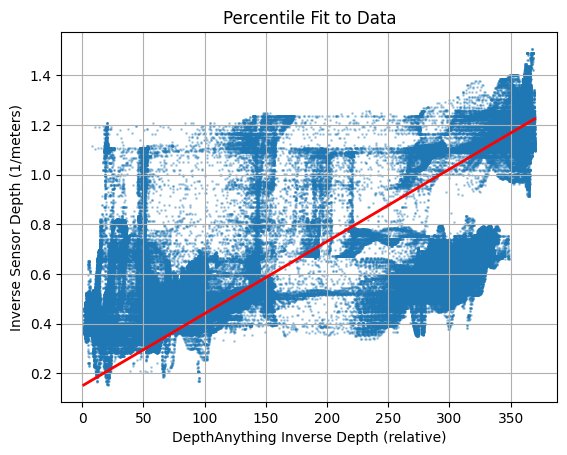

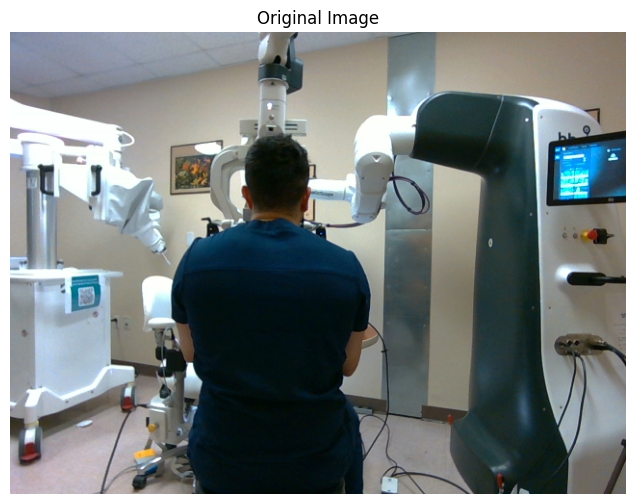

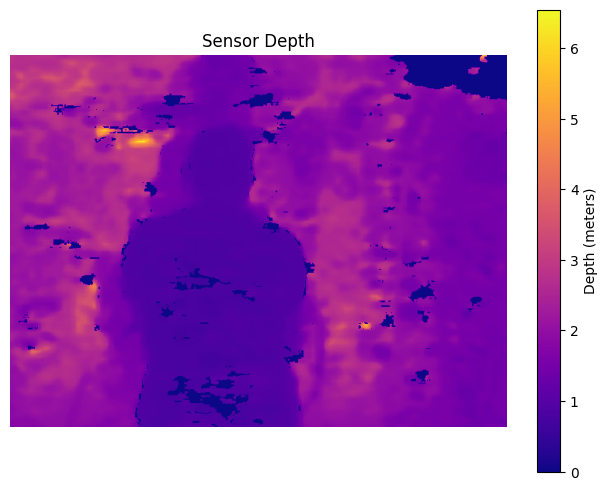

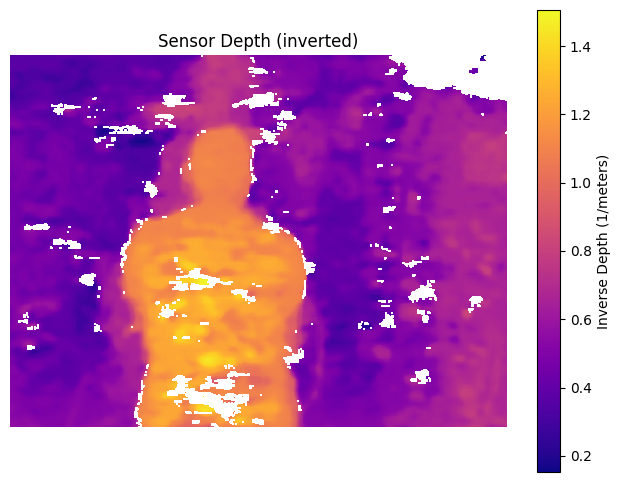

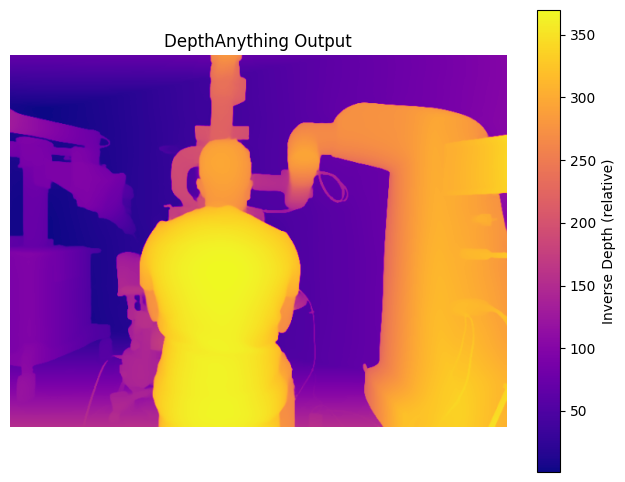

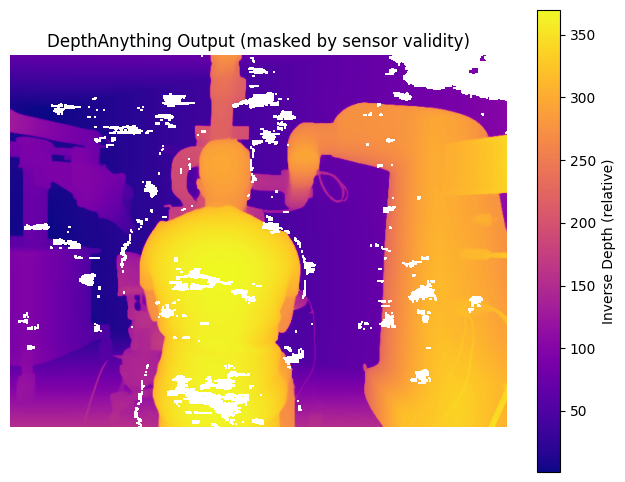

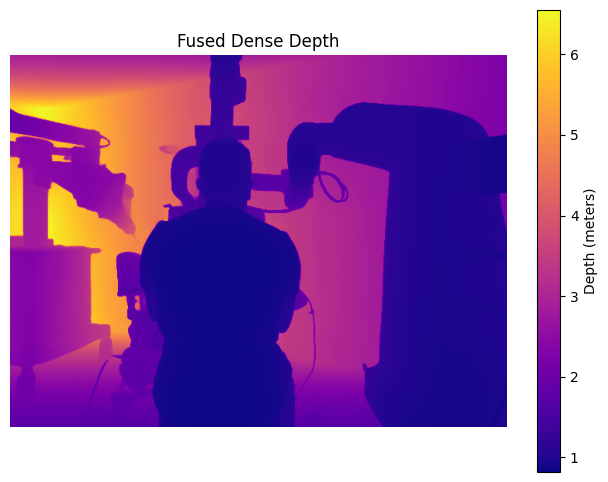

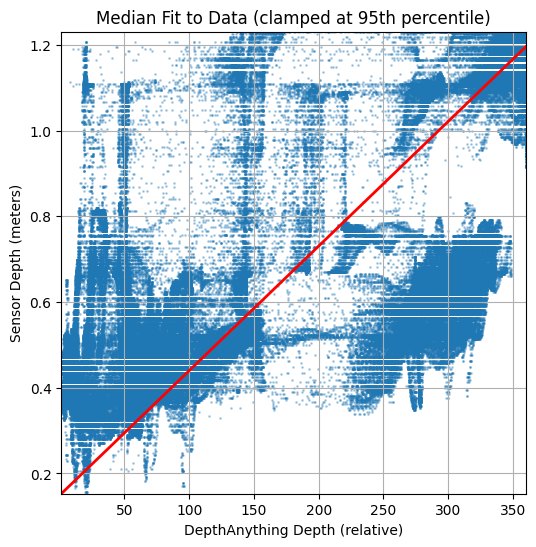

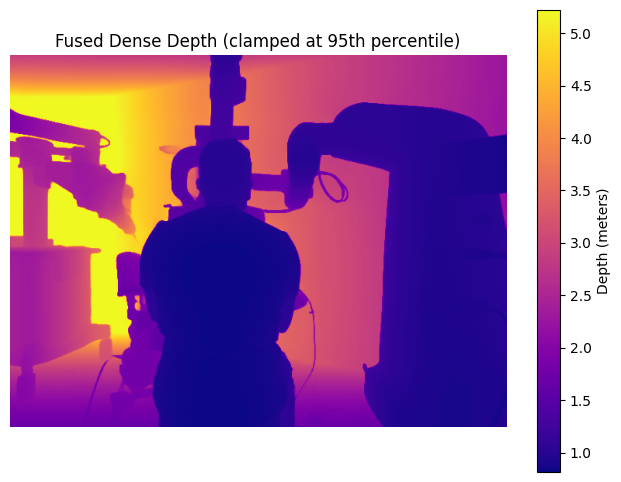

In [42]:
plot_all_figures("percentile")

Linear fit for example -> scale: 0.002, bias: 0.386


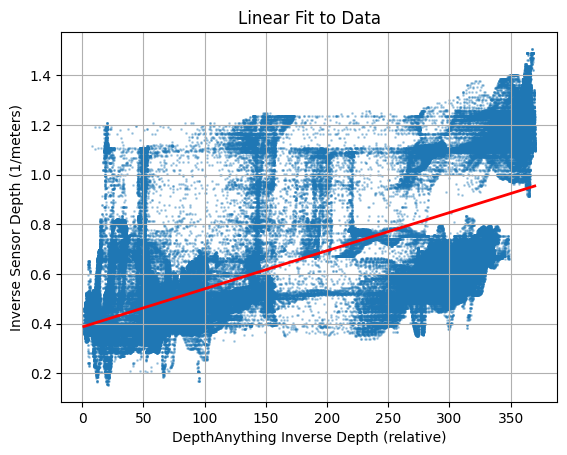

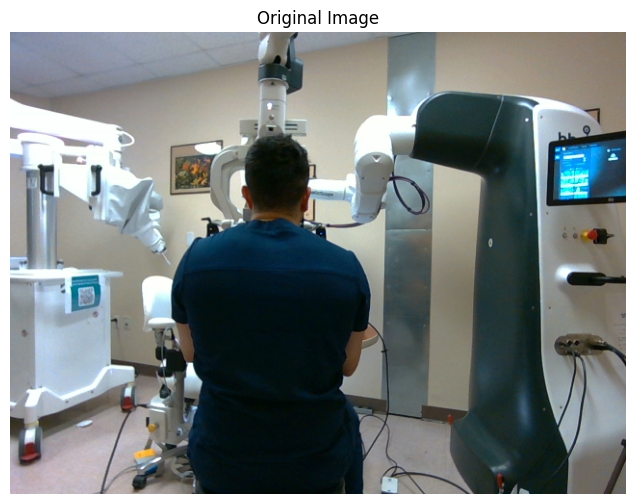

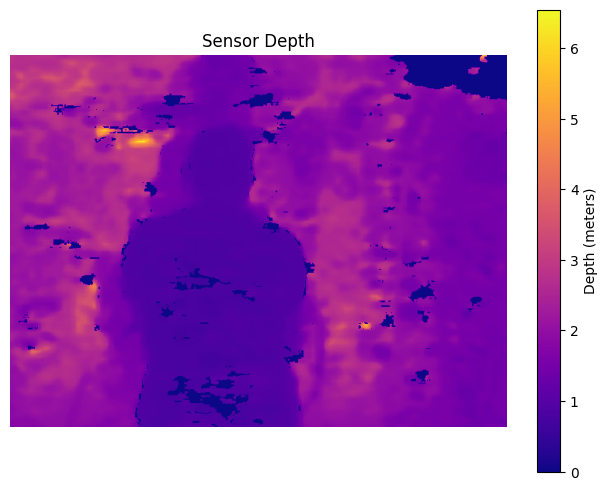

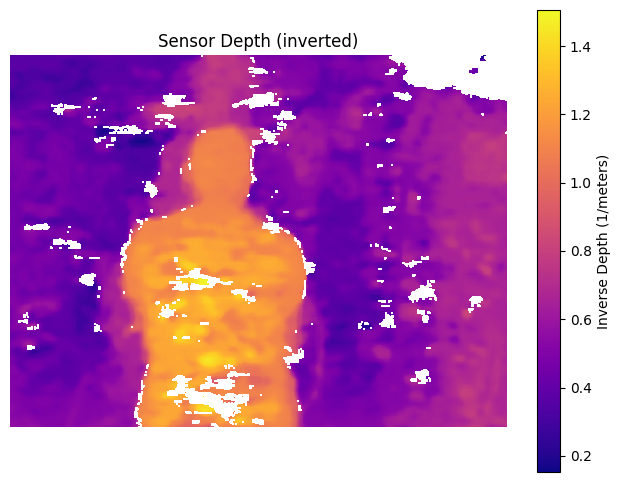

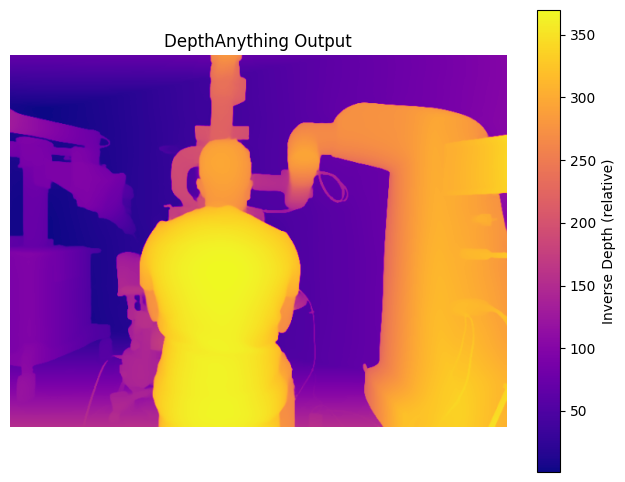

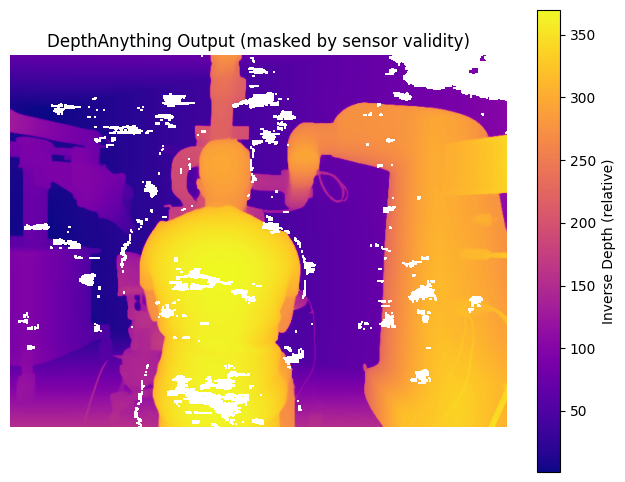

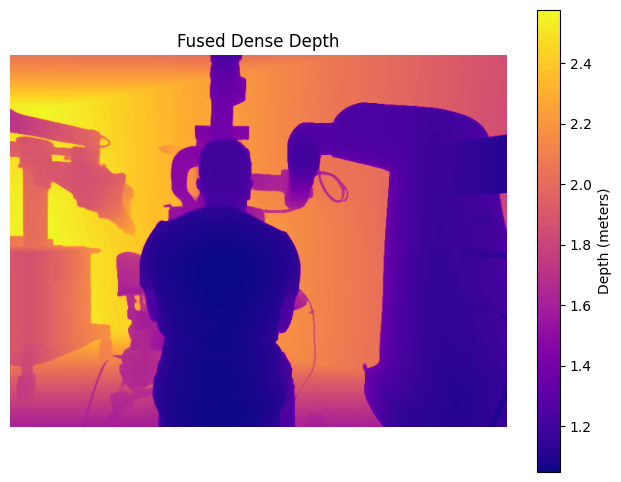

In [9]:
plot_all_figures("linear")